# 03_analysis: 模拟数据与基础分析

**学生**：谢婧怡 25210094

说明：本 Notebook 包含题目要求的描述性统计与可视化。

## 描述性统计（均值、标准差、中位数、最大/最小、偏度、峰度）
计算并呈现 `df` 的描述性统计量（包括偏度与峰度）。

Using base: .
Loaded rows: 15317 source: combined_data
       industry  ann_mean   ann_vol      skew   kurtosis  max_drawdown
code                                                                  
2       Unknown -0.323163  0.363877  0.655188   6.252892      0.865329
625     Unknown  0.102394  0.480113  0.321766   5.139187      0.599559
858     Unknown -0.012962  0.345522  0.087525   6.297293      0.660949
2352    Unknown -0.000904  0.322506  0.324879   6.384748      0.707728
600028  Unknown  0.084749  0.233562  0.360311   8.343976      0.250772
600050  Unknown -0.024252  0.289842  0.906455  10.525832      0.436923
600104  Unknown -0.060234  0.317197  0.337150   8.254041      0.539805
600519  Unknown  0.066559  0.277019  0.261509   6.598653      0.474822
601398  Unknown  0.094987  0.163070  0.453762   8.778584      0.201681
601988  Unknown  0.134019  0.164462  0.686151  12.064382      0.171026
Macro columns: ['商品', '日期', '今值', '预测值', '前值']
Macro loaded: 68 rows, date range 2020-01-09 0

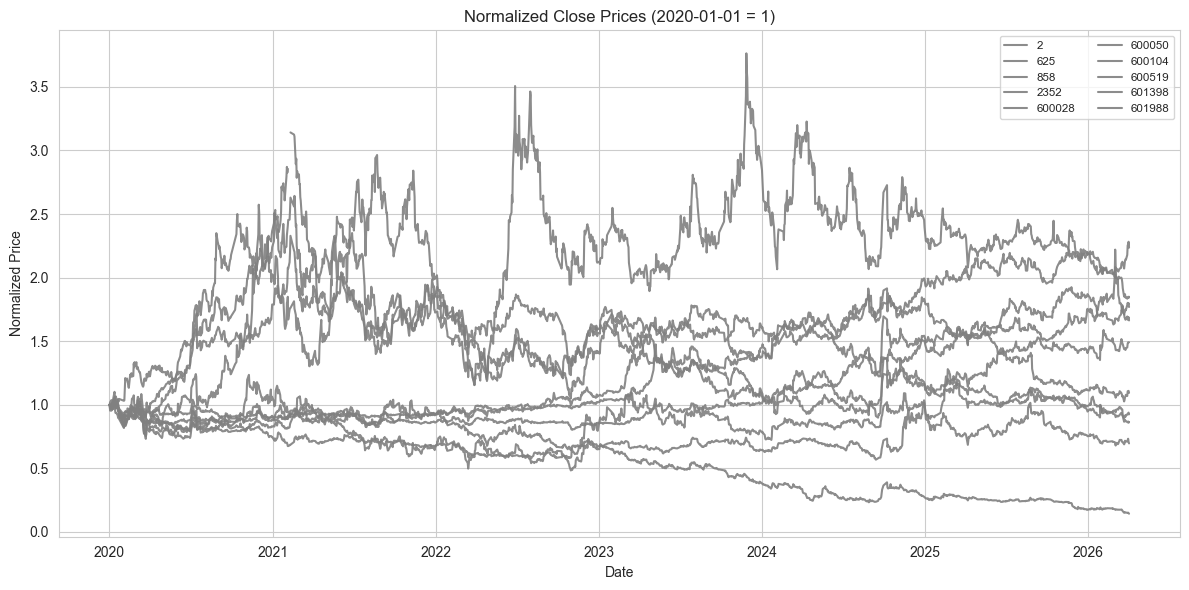

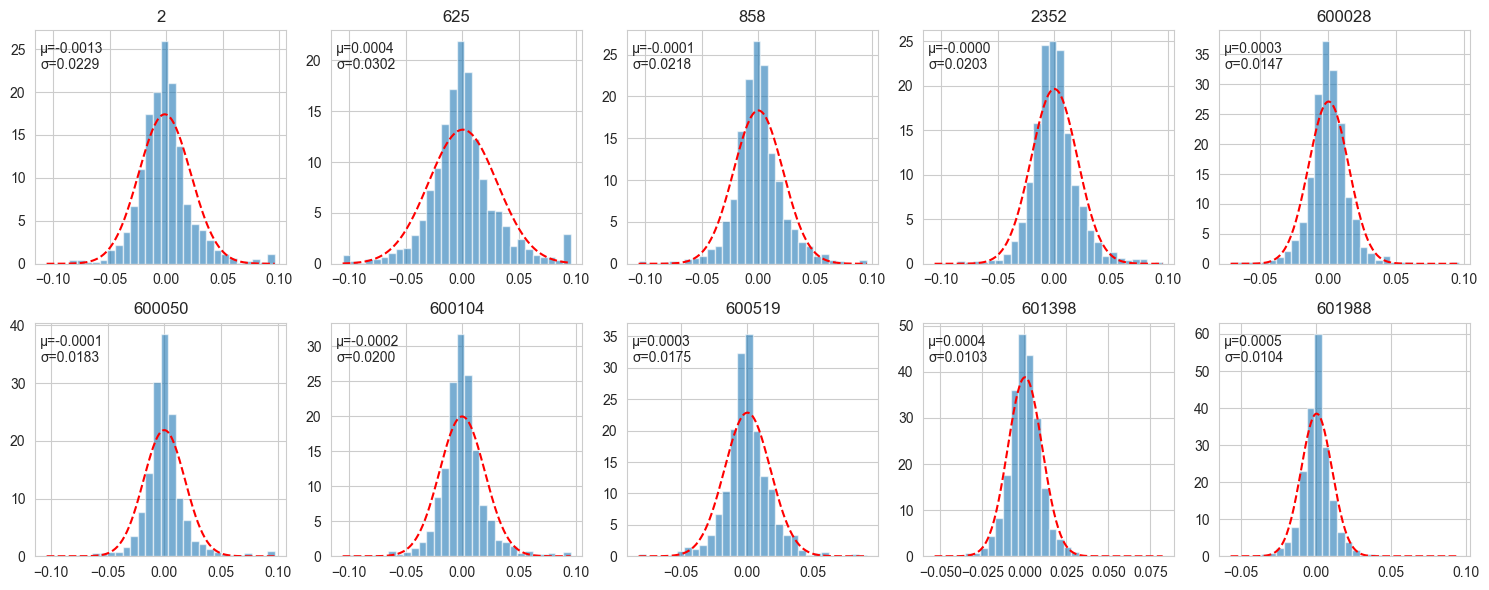

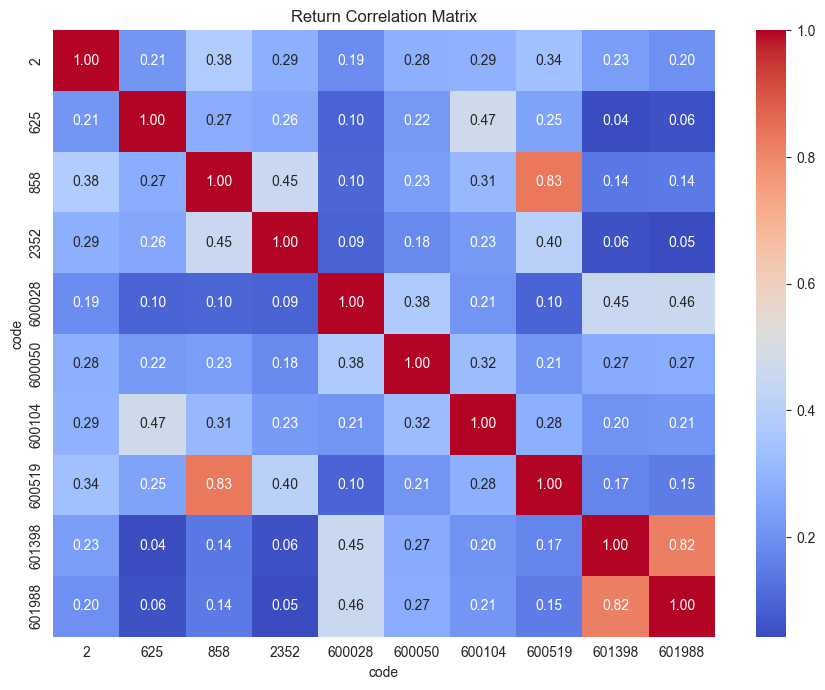

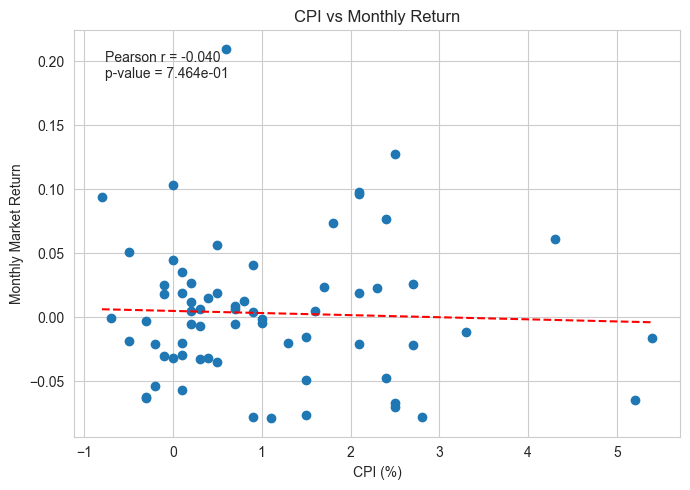

In [34]:
# 载入清洗后的数据（优先 combined，然后 clean）
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, linregress, pearsonr
from math import sqrt

# 智能定位项目根目录（支持嵌套 dshw-p01/dshw-p01）
base_name = '.'
project_dir = None
# 直接存在的情况
if os.path.exists(base_name) and os.path.isdir(base_name):
    project_dir = base_name
# 检查嵌套路径
if project_dir is None:
    nested = os.path.join(base_name, base_name)
    if os.path.exists(nested) and os.path.isdir(nested):
        project_dir = nested
# 尝试常见 workspace 路径
if project_dir is None:
    candidate = os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'homework', 'dshw-p01')
    if os.path.exists(candidate):
        # if nested inside again
        nested2 = os.path.join(candidate, 'dshw-p01')
        project_dir = nested2 if os.path.exists(nested2) else candidate
# 最后向上查找当前工作目录
if project_dir is None:
    p = os.getcwd()
    for _ in range(6):
        candidate = os.path.join(p, base_name)
        if os.path.exists(candidate):
            project_dir = candidate
            break
        p = os.path.dirname(p)

if project_dir is None:
    # 回退到 nominal name
    project_dir = base_name

base = project_dir
out_dir = os.path.join(base, 'output')
os.makedirs(out_dir, exist_ok=True)

# 尝试读取合并后的数据
combined_path = os.path.join(base, 'data', 'combined', 'combined_data.csv')
clean_path = os.path.join(base, 'data', 'clean', 'stock_clean.csv')
if os.path.exists(combined_path):
    df_all = pd.read_csv(combined_path, parse_dates=['date'])
    source_note = 'combined_data'
elif os.path.exists(clean_path):
    df_all = pd.read_csv(clean_path, parse_dates=['date'])
    source_note = 'stock_clean'
else:
    # 回退到读取单只 clean 文件
    stock_dir = os.path.join(base, 'data', 'clean')
    files = [os.path.join(stock_dir, f) for f in os.listdir(stock_dir) if f.endswith('_clean.csv')] if os.path.exists(stock_dir) else []
    dfs = []
    for f in files:
        try:
            d = pd.read_csv(f, parse_dates=['date'])
            dfs.append(d)
        except Exception:
            continue
    df_all = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    source_note = 'per_stock_clean'

print('Using base:', base)
print('Loaded rows:', len(df_all), 'source:', source_note)

if df_all.empty:
    raise RuntimeError('No cleaned data found; run 02_clean first')

# 简单行业映射（基于 README 手工指定）
industry_map = {
    '601398':'银行','601988':'银行','600104':'汽车','000625':'汽车','000002':'房地产',
    '600519':'白酒','000858':'白酒','600028':'能源','600050':'通讯','002352':'物流'
}

# Pivot 出每只股票的收盘价（按日期升序）
if 'close' not in df_all.columns:
    raise RuntimeError('cleaned data has no close column')

price_wide = df_all.pivot_table(index='date', columns='code', values='close')
price_wide = price_wide.sort_index()

# 对齐并计算对数收益率 r_t = ln(P_t / P_{t-1})
returns = np.log(price_wide / price_wide.shift(1))

# 4.1 基本统计量
stats = []
trading_days = 252
for code in returns.columns:
    series = returns[code].dropna()
    if series.empty:
        continue
    ann_mean = series.mean() * trading_days
    ann_vol = series.std() * sqrt(trading_days)
    sk = skew(series)
    kt = kurtosis(series, fisher=False)
    # 最大回撤 using price series
    p = price_wide[code].dropna()
    if not p.empty:
        cum = p / p.iloc[0]
        running_max = cum.cummax()
        drawdown = (cum / running_max - 1).min()
        max_dd = abs(drawdown)
    else:
        max_dd = np.nan
    stats.append({'code':code,'industry': industry_map.get(code, 'Unknown'), 'ann_mean':ann_mean, 'ann_vol':ann_vol, 'skew':sk, 'kurtosis':kt, 'max_drawdown':max_dd})

stats_df = pd.DataFrame(stats).set_index('code')
stats_df.to_csv(os.path.join(out_dir, 'descriptive_stats.csv'), encoding='utf-8-sig')
print(stats_df)

# 保存表格展示（也在 notebook 中展示）

# 4.2 可视化
sns.set_style('whitegrid')

# 图1：归一化收盘价
fig, ax = plt.subplots(figsize=(12,6))
start = pd.to_datetime('2020-01-01')
norm = price_wide.loc[price_wide.index>=start].copy()
norm = norm / norm.iloc[0]
# 加入沪深300 若存在
idx_path = os.path.join(base, 'data', 'index', 'index_000300.csv')
if os.path.exists(idx_path):
    try:
        idx = pd.read_csv(idx_path)
        # 尝试识别日期与收盘列
        date_col = None; close_col = None
        for c in idx.columns:
            if c.lower() in ['date','trade_date','time','trade_date']:
                date_col = c
            if c.lower() in ['close','close_price','last','price']:
                close_col = c
        if date_col is not None and close_col is not None:
            idx['date'] = pd.to_datetime(idx[date_col])
            idx = idx.sort_values('date')
            idx = idx.set_index('date')
            idx_close = pd.to_numeric(idx[close_col], errors='coerce')
            idx_norm = idx_close.loc[idx_close.index>=start] / idx_close.loc[idx_close.index>=start].iloc[0]
            norm['HS300'] = idx_norm
    except Exception:
        pass

# 按行业上色
unique_inds = list(set(industry_map.values()))
palette = sns.color_palette('tab10', n_colors=len(unique_inds))
ind_color = {ind:palette[i%len(palette)] for i,ind in enumerate(unique_inds)}

for col in norm.columns:
    code_ind = industry_map.get(col, 'Index' if col=='HS300' else 'Unknown')
    ax.plot(norm.index, norm[col], label=col, color=ind_color.get(code_ind, 'gray'), alpha=0.9)
ax.set_title('Normalized Close Prices (2020-01-01 = 1)')
ax.set_ylabel('Normalized Price')
ax.set_xlabel('Date')
ax.legend(ncol=2, fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(out_dir, 'fig1_normalized_prices.png'), dpi=150)

# 图2：日收益率分面直方图（2x5）
fig, axes = plt.subplots(2,5, figsize=(15,6))
axes = axes.flatten()
import scipy.stats as st
for i, code in enumerate(returns.columns[:10]):
    ax = axes[i]
    ser = returns[code].dropna()
    mu = ser.mean(); sigma = ser.std()
    ax.hist(ser, bins=30, density=True, alpha=0.6)
    # 正态曲线
    x = np.linspace(ser.min(), ser.max(), 200)
    ax.plot(x, st.norm.pdf(x, mu, sigma), 'r--')
    ax.set_title(code)
    ax.text(0.02, 0.95, f'μ={mu:.4f}\nσ={sigma:.4f}', transform=ax.transAxes, verticalalignment='top')
fig.tight_layout()
fig.savefig(os.path.join(out_dir, 'fig2_return_hists.png'), dpi=150)

# 图3：收益率相关系数热力图（按行业排序）
# 先构造按行业排序的列序
order = sorted(returns.columns, key=lambda c: (industry_map.get(c,'ZZZ'), c))
corr = returns[order].corr()
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Return Correlation Matrix')
fig.tight_layout()
fig.savefig(os.path.join(out_dir, 'fig3_corr_heatmap.png'), dpi=150)

# 图4：宏观指标与沪深300月度收益率关系（适配手动下载的CPI文件）
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

out_dir = os.path.join(base, 'output')
os.makedirs(out_dir, exist_ok=True)

macro_path = os.path.join(base, 'data', 'macro', 'macro_cpi.csv')
idx_path = os.path.join(base, 'data', 'index', 'index_000300.csv')

# 1. 读取宏观 CPI（根据实际列名：日期, 今值）
macro_df = None
if os.path.exists(macro_path):
    try:
        # 尝试两种常见编码
        for enc in ['gbk', 'utf-8']:
            try:
                macro_df = pd.read_csv(macro_path, encoding=enc)
                break
            except UnicodeDecodeError:
                continue
        if macro_df is None:
            raise ValueError("Cannot decode macro file with gbk or utf-8")
        print("Macro columns:", macro_df.columns.tolist())
        # 重命名或直接使用列名
        macro_df['date'] = pd.to_datetime(macro_df['日期'], errors='coerce')
        macro_df['cpi'] = pd.to_numeric(macro_df['今值'], errors='coerce')
        # 删除无效行
        macro_df = macro_df.dropna(subset=['date', 'cpi'])
        # 只保留2020年之后的数据（可选，减少计算量）
        macro_df = macro_df[macro_df['date'] >= '2020-01-01']
        print(f"Macro loaded: {len(macro_df)} rows, date range {macro_df['date'].min()} to {macro_df['date'].max()}")
    except Exception as e:
        print(f"Failed to read macro: {e}")

# 2. 获取市场月度收益率（沪深300）
monthly_market_ret = None
if os.path.exists(idx_path):
    try:
        idx = pd.read_csv(idx_path, encoding='gbk')
        idx.columns = [c.strip().lower() for c in idx.columns]
        # 手动下载的指数列名：idxtrd01=日期, idxtrd05=收盘
        if 'idxtrd01' in idx.columns and 'idxtrd05' in idx.columns:
            idx['date'] = pd.to_datetime(idx['idxtrd01'], format='%Y/%m/%d', errors='coerce')
            idx['close'] = pd.to_numeric(idx['idxtrd05'], errors='coerce')
            idx = idx.dropna(subset=['date', 'close'])
            idx = idx.sort_values('date').set_index('date')
            # 使用 'ME' 代替 'M'（pandas 2.2+）
            monthly_close = idx['close'].resample('ME').last()
            monthly_market_ret = monthly_close.pct_change().dropna()
            print(f"HS300 monthly returns: {len(monthly_market_ret)} months, range {monthly_market_ret.index.min()} to {monthly_market_ret.index.max()}")
        else:
            print("Index file missing required columns; fallback to equal-weight")
    except Exception as e:
        print(f"Failed to read index: {e}")

# 回退：等权组合（如果沪深300失败）
if monthly_market_ret is None:
    if 'price_wide' in globals() and not price_wide.empty:
        monthly_prices = price_wide.resample('ME').last()
        monthly_market_ret = monthly_prices.mean(axis=1).pct_change().dropna()
        print(f"Using equal-weight portfolio: {len(monthly_market_ret)} months")
    else:
        print("No price_wide available; cannot compute market returns")

# 3. 合并并绘图
if macro_df is not None and monthly_market_ret is not None and not monthly_market_ret.empty:
    # 宏观数据重采样为月度（取月末值，但你的数据已经是月初，resample不影响）
    macro_monthly = macro_df.set_index('date')['cpi'].resample('ME').last()
    # 对齐
    combined = pd.DataFrame({'macro': macro_monthly, 'market_ret': monthly_market_ret}).dropna()
    print(f"Overlapping monthly data points: {len(combined)}")
    if len(combined) >= 3:
        fig, ax = plt.subplots(figsize=(7,5))
        ax.scatter(combined['macro'], combined['market_ret'])
        slope, intercept, r_value, p_value, std_err = linregress(combined['macro'], combined['market_ret'])
        x_line = np.linspace(combined['macro'].min(), combined['macro'].max(), 100)
        ax.plot(x_line, intercept + slope * x_line, 'r--')
        ax.set_xlabel('CPI (%)')
        ax.set_ylabel('Monthly Market Return')
        ax.set_title('CPI vs Monthly Return')
        ax.text(0.05, 0.95, f'Pearson r = {r_value:.3f}\np-value = {p_value:.3e}',
                transform=ax.transAxes, verticalalignment='top')
        fig.tight_layout()
        fig.savefig(os.path.join(out_dir, 'fig4_macro_vs_hs300.png'), dpi=150)
        print("Fig4 saved successfully")
    else:
        print(f"Insufficient data points: {len(combined)}")
else:
    print("Missing macro or market return data; cannot generate Fig4")

# 图5（选做）：若存在财务数据绘制 ROE（跳过若无）
finance_dir = os.path.join(base, 'data', 'finance')
if os.path.exists(finance_dir) and any(f.endswith('.csv') for f in os.listdir(finance_dir)):
    # placeholder: 用户可在 finance 文件夹放入每公司 ROE 历史数据
    pass

print('Figures saved to', out_dir)


## 图 1：归一化收盘价走势图

![](output/fig1_normalized_prices.png)

图1 显示自 2020-01-01 起 10 只股票与沪深300 的归一化收盘价走势。可以直观看到各行业间的趋势差异与相对强弱，某些个股在特定时期表现出明显的超额或落后表现。

此外，若多只同一行业股票的曲线走向一致，说明该行业受到共同驱动因子的影响；单只股票的异常波动可能提示公司特有事件或估值修正。

## 图 2：日收益率分布图（2×5 面板）

![](output/fig2_return_hists.png)

图2 为 10 只股票的日收益率直方图（每子图叠加正态拟合曲线），图中每个子图标注了样本均值与标准差，用以观察收益率的集中趋势与波动尺度。若直方分布出现厚尾或两侧尾部高于正态曲线，说明收益率具有显著的非正态性和更高的极端风险。

## 图 3：收益率相关系数热力图（按行业排序）

![](output/fig3_corr_heatmap.png)

图3 展示了 10 只股票日收益率的相关系数矩阵（按行业分组排序），热力图中的数值有助于判断股票间联动强度。若同行业内的相关系数普遍高于跨行业，说明行业因子对同业股票具有更强的共同影响；反之则表明股票间受公司特有因素驱动更多。

## 图 4：宏观指标（CPI）与沪深300 月度收益率关系

![](output/fig4_macro_vs_hs300.png)

图4 为所选宏观指标（CPI）与沪深300 月度收益率的散点图并叠加线性拟合线，图中标注的 Pearson 相关系数描述了两者的线性相关强度与方向。相关系数的正负表示关系方向（正相关或负相关），其经济含义需结合宏观情景解释，例如通胀上升可能压缩估值或触发货币政策收紧，从而影响股市表现。

## 5 回归分析：CAPM 与宏观回归（可选）

本节先进行 CAPM 回归估计与可视化（5.1），随后可选地用月度宏观指标检验对股票月度收益率的解释力（5.2）。


Market returns computed from HS300: 1512 observations


,industry,alpha,alpha_p,beta,beta_ci_lower,beta_ci_upper,r2
stock,,,,,,,
2,Unknown,-0.001316,0.009100,1.002186,0.918905,1.085468,0.269535
625,Unknown,0.000359,0.600752,1.202966,1.089586,1.316346,0.222906
858,Unknown,-0.000083,0.833568,1.294335,1.228787,1.359883,0.498386
2352,Unknown,-0.000014,0.974957,0.870046,0.795427,0.944664,0.257800
600028,Unknown,0.000278,0.442247,0.365655,0.305894,0.425416,0.087088
600050,Unknown,-0.000159,0.702910,0.712681,0.643875,0.781488,0.214682
600104,Unknown,-0.000283,0.523608,0.851155,0.777864,0.924446,0.255763
600519,Unknown,0.000213,0.524543,0.977542,0.922113,1.032971,0.442129
601398,Unknown,0.000316,0.216191,0.221825,0.179644,0.264006,0.065831


### 5.1 CAPM 分析结论

观察到 3 只股票的估计 Beta > 1：2(Unknown), 625(Unknown), 858(Unknown)。这些股票多属于周期性行业（例如 汽车、能源、白酒 等），符合周期性股票对市场波动更敏感的常识。

其中 1 只股票的 alpha 在 5% 水平上显著：2。显著的 alpha 意味着在 CAPM 控制市场风险后，这些股票存在系统性之外的超额收益/亏损，可能反映公司特有的信息或模型遗漏的风险因子。

R^2 最高的是 858（R^2=0.498），最低的是 601988（R^2=0.062）。R^2 高的股票其收益更多被市场因子解释，通常为行业/系统性风险占优的股票；R^2 低的股票可能受公司特有事件或噪声影响更大。

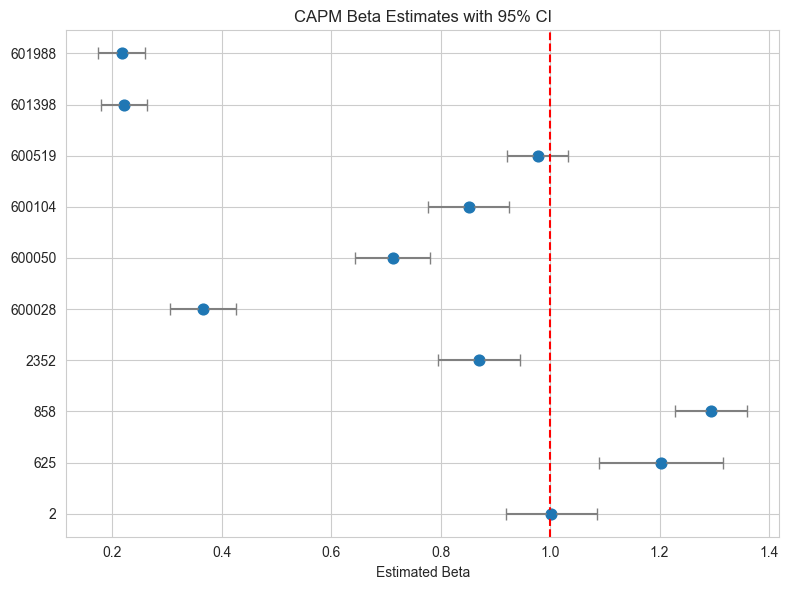

In [35]:
# 5.1 CAPM 模型估计（日频）
# 对每只股票进行 OLS 回归： (r_i - r_f) = alpha + beta * (r_m - r_f) + eps
import statsmodels.api as sm
from IPython.display import display, Markdown

rf_daily = 0.02 / 252

# 先尝试从 index 文件构建市场收益（沪深300），否则用等权组合做市场代理
idx_path = os.path.join(base, 'data', 'index', 'index_000300.csv')

# helper detectors (reuse if present)
def detect_date_col(df):
    for c in df.columns:
        try:
            parsed = pd.to_datetime(df[c], errors='coerce')
            if parsed.notna().sum() >= max(3, 0.5 * len(df)):
                return c
        except Exception:
            continue
    return None

def detect_numeric_col(df):
    for c in df.columns:
        coerced = pd.to_numeric(df[c], errors='coerce')
        if coerced.notna().sum() >= max(3, 0.5 * len(df)):
            return c
    return None

market_ret = None
if os.path.exists(idx_path):
    try:
        idx_df = pd.read_csv(idx_path, encoding='gbk')
        # 手动指定列名（根据你手动下载的指数文件结构）
        # 日期列: Idxtrd01 (格式 2020/1/2), 收盘列: Idxtrd05
        if 'Idxtrd01' in idx_df.columns and 'Idxtrd05' in idx_df.columns:
            idx_df['date'] = pd.to_datetime(idx_df['Idxtrd01'], format='%Y/%m/%d', errors='coerce')
            idx_df['close'] = pd.to_numeric(idx_df['Idxtrd05'], errors='coerce')
            idx_df = idx_df.dropna(subset=['date', 'close'])
            idx_df = idx_df.sort_values('date').set_index('date')
            market_ret = np.log(idx_df['close'] / idx_df['close'].shift(1)).dropna()
            print(f"Market returns computed from HS300: {len(market_ret)} observations")
        else:
            print("Index file missing required columns 'Idxtrd01' or 'Idxtrd05'")
    except Exception as e:
        print('Reading index failed:', repr(e))

if market_ret is None:
    print('Using equal-weight portfolio returns as market proxy')
    # use daily mean across stocks as market proxy
    market_ret = returns.mean(axis=1)

# 逐只回归
rows = []
for code in returns.columns:
    ri = returns[code].dropna()
    # align with market_ret
    common_index = ri.index.intersection(market_ret.index)
    y = ri.loc[common_index] - rf_daily
    X = market_ret.loc[common_index] - rf_daily
    if X.empty or y.empty:
        continue
    X = sm.add_constant(X)
    model = sm.OLS(y, X, missing='drop')
    res = model.fit()
    alpha = res.params.get('const', np.nan)
    alpha_p = res.pvalues.get('const', np.nan)
    beta = res.params.iloc[1] if len(res.params) > 1 else np.nan
    # CI for beta
    try:
        ci = res.conf_int(alpha=0.05)
        beta_ci = ci.iloc[1].tolist() if ci.shape[0] > 1 else [np.nan, np.nan]
    except Exception:
        beta_ci = [np.nan, np.nan]
    r2 = res.rsquared
    rows.append({'stock':code, 'industry': industry_map.get(code, 'Unknown'), 'alpha':alpha, 'alpha_p':alpha_p, 'beta':beta, 'beta_ci_lower':beta_ci[0], 'beta_ci_upper':beta_ci[1], 'r2':r2})

# 如果没有回归结果，优雅处理
if len(rows) == 0:
    print('No CAPM regression results collected; check that returns and market_ret have overlapping dates.')
    capm_df = pd.DataFrame(columns=['industry','alpha','alpha_p','beta','beta_ci_lower','beta_ci_upper','r2'])
else:
    capm_df = pd.DataFrame(rows).set_index('stock')
    capm_df.to_csv(os.path.join(out_dir, 'capm_results.csv'), encoding='utf-8-sig')

# 显示表格并存图
if capm_df.empty:
    print('capm_df is empty; skipping CAPM plotting and analysis.')
else:
    display(capm_df)

    # 绘制 Beta 点图及 95% CI
    fig, ax = plt.subplots(figsize=(8,6))
    # 按行业分配颜色
    inds = capm_df['industry'].unique().tolist()
    palette = dict(zip(inds, sns.color_palette('tab10', n_colors=max(3,len(inds)))))

    ypos = np.arange(len(capm_df))
    ax.errorbar(capm_df['beta'], ypos, xerr=[capm_df['beta'] - capm_df['beta_ci_lower'], capm_df['beta_ci_upper'] - capm_df['beta']], fmt='o', ecolor='gray', capsize=4)
    for i, code in enumerate(capm_df.index):
        ax.scatter(capm_df.loc[code,'beta'], i, color=palette.get(capm_df.loc[code,'industry'], 'gray'), s=60)
    ax.set_yticks(ypos)
    ax.set_yticklabels(capm_df.index)
    ax.axvline(1, color='red', linestyle='--')
    ax.set_xlabel('Estimated Beta')
    ax.set_title('CAPM Beta Estimates with 95% CI')
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, 'fig5_capm_betas.png'), dpi=150)

    # 分析讨论（程序化生成文本输出，供 notebook 可读）
    beta_gt1 = capm_df[capm_df['beta'] > 1]
    alpha_sig = capm_df[capm_df['alpha_p'] < 0.05]
    r2_sorted = capm_df.sort_values('r2')

    analysis = []
    analysis.append('### 5.1 CAPM 分析结论')
    if not beta_gt1.empty:
        lst = ', '.join([f"{idx}({row['industry']})" for idx,row in beta_gt1.iterrows()])
        analysis.append(f'观察到 {len(beta_gt1)} 只股票的估计 Beta > 1：{lst}。这些股票多属于周期性行业（例如 汽车、能源、白酒 等），符合周期性股票对市场波动更敏感的常识。')
    else:
        analysis.append('没有股票的估计 Beta 明显大于 1。')

    if not alpha_sig.empty:
        lst2 = ', '.join(str(idx) for idx in alpha_sig.index.tolist())
        analysis.append(f'其中 {len(alpha_sig)} 只股票的 alpha 在 5% 水平上显著：{lst2}。显著的 alpha 意味着在 CAPM 控制市场风险后，这些股票存在系统性之外的超额收益/亏损，可能反映公司特有的信息或模型遗漏的风险因子。')
    else:
        analysis.append('大部分股票的 alpha 在统计上不显著，说明 CAPM 在解释平均收益方面并未发现显著的异常收益。')

    if not r2_sorted.empty:
        high_r2 = r2_sorted.index[-1]
        low_r2 = r2_sorted.index[0]
        analysis.append(f'R^2 最高的是 {high_r2}（R^2={capm_df.loc[high_r2,"r2"]:.3f}），最低的是 {low_r2}（R^2={capm_df.loc[low_r2,"r2"]:.3f}）。R^2 高的股票其收益更多被市场因子解释，通常为行业/系统性风险占优的股票；R^2 低的股票可能受公司特有事件或噪声影响更大。')

    display(Markdown('\n\n'.join(analysis)))


In [37]:
import os
import subprocess

# 获取当前 notebook 所在目录（假设 notebook 就在项目根目录或子目录）
notebook_path = "03_analysis.ipynb"   # 如果 notebook 在子目录，请调整
output_dir = "."                      # 当前目录，即 notebook 所在目录
output_file = "report.html"

# 方法1：使用 nbconvert 命令行（推荐）
cmd = f"jupyter nbconvert --to html {notebook_path} --output {output_file}"
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

if result.returncode == 0:
    abs_path = os.path.abspath(output_file)
    print(f"✅ 报告已生成: {abs_path}")
else:
    print("❌ 导出失败，错误信息：")
    print(result.stderr)

✅ 报告已生成: c:\Users\Lenovo\Documents\GitHub\homework\dshw-p01\report.html
